# Fashion MNIST

Fashion Mnist는 옷, 바지 등 10가지 종류의 의류로 구성된 데이터입니다. 이 데이터는 (28, 28) 크기로 구성되어 있으며 Training Set 6만장, Test Set 1만장으로 총합 7만장으로 이루어져 있습니다. Keras에서 dataset을 import 할 수 있고, 처음 import 시 다운로드 하는 과정이 추가됩니다.

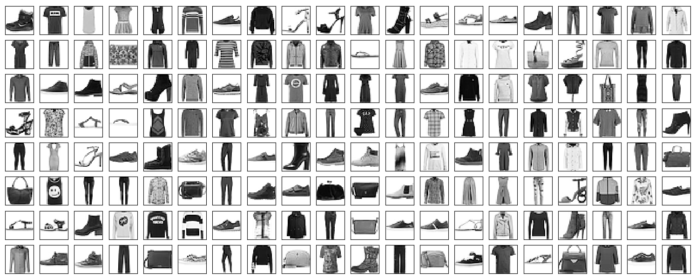


## 데이터 로드

In [1]:
import tensorflow as tf

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### 데이터 shape 확인

In [3]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


### 이미지 출력
#### 5 x 5로 이미지 출력
#### cmap='gray_r'  

In [4]:
import matplotlib.pyplot as plt

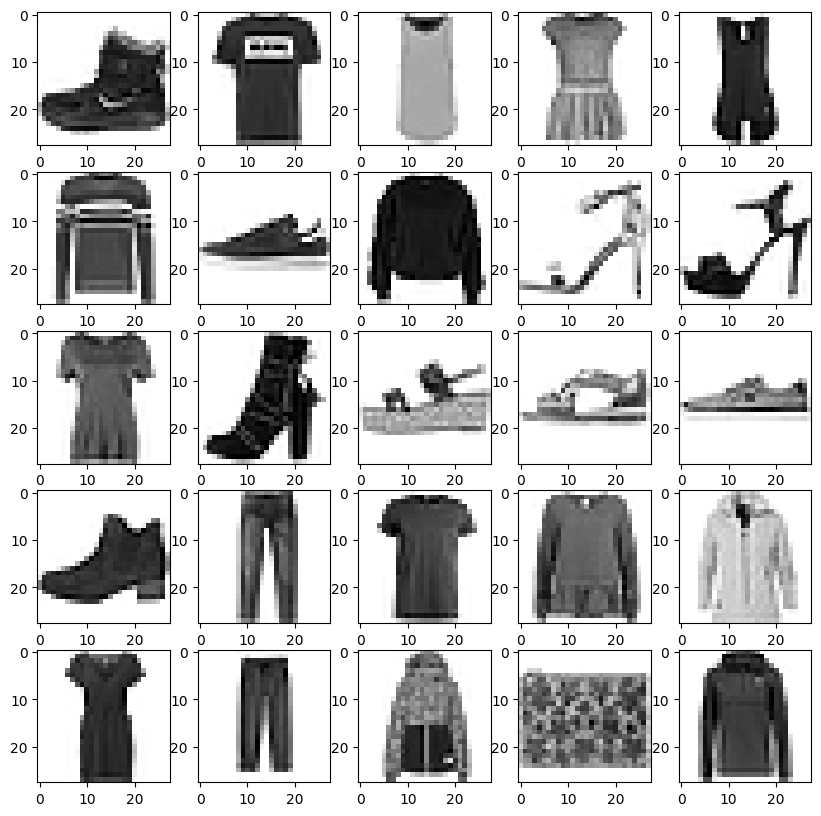

In [5]:
fig, axs = plt.subplots(5,5, figsize=(10, 10))
for i in range(5):
  for j in range(5):
    axs[i, j].imshow(x_train[i*5+j], cmap='gray_r')
plt.show()


## class 확인

In [6]:
items = {0:'T-shirt/top', 1:'Trouser', 2:'Pullover', 3:'Dress',
         4:'Coat', 5:'Sandal', 6:'Shirt', 7:'Sneaker',
         8:'Bag', 9:'Ankel boot'}

In [7]:
y_train[0:25]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5, 0, 9, 5, 5, 7, 9, 1, 0, 6, 4, 3, 1,
       4, 8, 4], dtype=uint8)

In [9]:
print([items[i] for i in y_train[:25]])

['Ankel boot', 'T-shirt/top', 'T-shirt/top', 'Dress', 'T-shirt/top', 'Pullover', 'Sneaker', 'Pullover', 'Sandal', 'Sandal', 'T-shirt/top', 'Ankel boot', 'Sandal', 'Sandal', 'Sneaker', 'Ankel boot', 'Trouser', 'T-shirt/top', 'Shirt', 'Coat', 'Dress', 'Trouser', 'Coat', 'Bag', 'Coat']


In [10]:
import numpy as np

In [11]:
np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

In [12]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [13]:
print([items[i] for i in np.unique(y_train)])

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankel boot']


## 검증데이터(validation data) 생성

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
x_train1, x_val, y_train1, y_val = train_test_split(x_train, y_train, test_size=0.2,random_state=42)

In [16]:
print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(12000, 28, 28) (12000,)
(10000, 28, 28) (10000,)


## one-hot encoding

In [17]:
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_val = tf.keras.utils.to_categorical(y_val, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

In [18]:
print(y_train.shape, y_val.shape, y_test.shape)

(60000, 10) (12000, 10) (10000, 10)


## 정규화(Normalization)

In [19]:
x_train = x_train / 255
x_val = x_val / 255
x_test = x_test / 255

In [20]:
print(x_val[0:10])

[[[0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  ...
  [0.00784314 0.         0.43921569 ... 0.         0.         0.00392157]
  [0.00784314 0.         0.08235294 ... 0.         0.00392157 0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]]

 [[0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  ...
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]]

 [[0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.      

## 직렬화

In [21]:
x_train = x_train.reshape(-1, 28 * 28)
x_val = x_val.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

In [22]:
print(x_train.shape, x_val.shape, x_test.shape)

(60000, 784) (12000, 784) (10000, 784)


## model 생성

In [23]:
from tensorflow.keras import layers, models

In [43]:
#784-128-64-32-10
model = models.Sequential([
    layers.Dense(128, activation='sigmoid', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
model.compile(loss='categorical_crossentropy', metrics=['acc'])

## 학습

In [45]:
history = model.fit(x_train, y_train, epochs=30, validation_data=(x_val, y_val))

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - acc: 0.8044 - loss: 0.5390 - val_acc: 0.8495 - val_loss: 0.4162
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8558 - loss: 0.3958 - val_acc: 0.8703 - val_loss: 0.3549
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.8690 - loss: 0.3572 - val_acc: 0.8766 - val_loss: 0.3395
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.8774 - loss: 0.3351 - val_acc: 0.8875 - val_loss: 0.3030
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8860 - loss: 0.3175 - val_acc: 0.8863 - val_loss: 0.3079
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - acc: 0.8874 - loss: 0.3052 - val_acc: 0.8810 - val_loss: 0.3232
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.8919 - loss: 0.2950 - val_acc: 0.8911 - val_loss: 0.2872
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.8947 - loss: 0.2883 - val_acc: 0.8943 - val_loss: 0.2936
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━

## 학습곡선

In [47]:
history.history

{'acc': [0.8044166564941406,
  0.8558333516120911,
  0.8689833283424377,
  0.8773833513259888,
  0.8859500288963318,
  0.8873500227928162,
  0.8919333219528198,
  0.8947499990463257,
  0.8978166580200195,
  0.8998333215713501,
  0.9016500115394592,
  0.9043499827384949,
  0.9058499932289124,
  0.9068166613578796,
  0.9090166687965393,
  0.9094666838645935,
  0.9093666672706604,
  0.9119833111763,
  0.912850022315979,
  0.9139333367347717,
  0.9140999913215637,
  0.9157000184059143,
  0.9157500267028809,
  0.917116641998291,
  0.9174833297729492,
  0.9185333251953125,
  0.9203833341598511,
  0.9218500256538391,
  0.9226166605949402,
  0.9224333167076111],
 'loss': [0.5390087962150574,
  0.39575326442718506,
  0.3571716547012329,
  0.33513423800468445,
  0.31752273440361023,
  0.3052384555339813,
  0.29497647285461426,
  0.28827306628227234,
  0.27875998616218567,
  0.27421998977661133,
  0.2693311274051666,
  0.263276606798172,
  0.26001688838005066,
  0.2575102150440216,
  0.2553470134

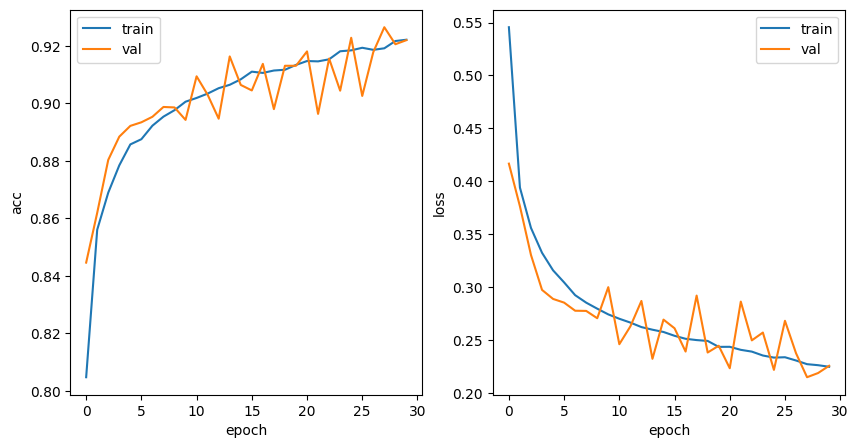

In [34]:
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.legend(['train', 'val'])
plt.xlabel('epoch')
plt.ylabel('acc')

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train', 'val'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

## 과대적합(Over fitting)/과소적합(Under fitting)

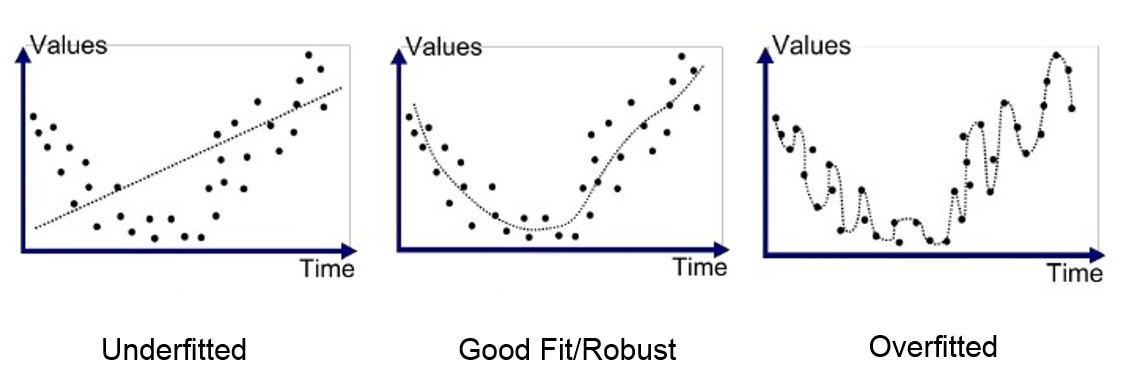

In [35]:
model1 = models.Sequential([
    layers.Dense(128, activation='sigmoid', input_shape=(784,)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
model1.compile(loss='categorical_crossentropy', metrics=['acc'])

In [37]:
history1 = model1.fit(x_train, y_train, epochs=30, validation_data=(x_val, y_val))

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - acc: 0.7784 - loss: 0.6078 - val_acc: 0.8428 - val_loss: 0.4205
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.8390 - loss: 0.4433 - val_acc: 0.8572 - val_loss: 0.3854
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8530 - loss: 0.4076 - val_acc: 0.8707 - val_loss: 0.3581
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8598 - loss: 0.3874 - val_acc: 0.8766 - val_loss: 0.3349
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.8664 - loss: 0.3746 - val_acc: 0.8840 - val_loss: 0.3132
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8698 - loss: 0.3656 - val_acc: 0.8820 - val_loss: 0.3209
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.8722 - loss: 0.3593 - val_acc: 0.8824 - val_loss: 0.3255
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8740 - loss: 0.3557 - val_acc: 0.8892 - val_loss: 0.3004
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━

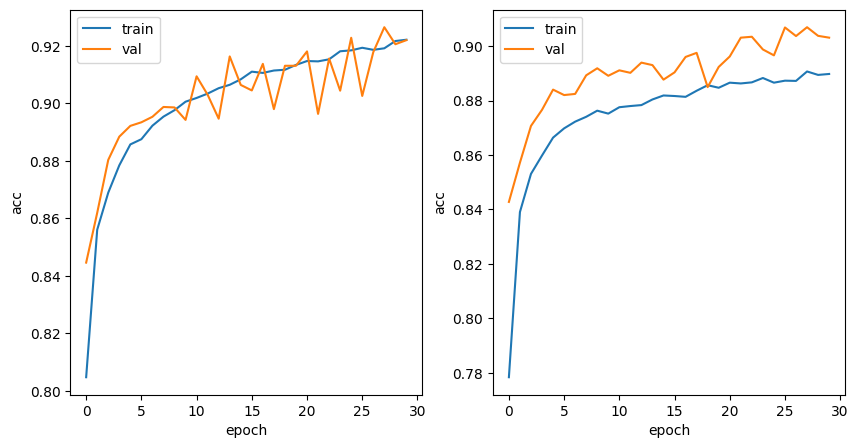

In [40]:
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.legend(['train', 'val'])
plt.xlabel('epoch')
plt.ylabel('acc')

plt.subplot(1,2,2)
plt.plot(history1.history['acc'])
plt.plot(history1.history['val_acc'])
plt.legend(['train', 'val'])
plt.xlabel('epoch')
plt.ylabel('acc')
plt.show()

In [41]:
model1.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.8750 - loss: 0.3677


[0.3677252233028412, 0.875]

In [46]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.8778 - loss: 0.6044


[0.604408860206604, 0.8777999877929688]

In [48]:
model.save('fmnist_nn.h5')

In [49]:
model3 = models.load_model('fmnist_nn.h5')

In [50]:
model3.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,148 (434.18 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)